# Cenário 3: Erros com Assimetria - Simulação MRLS

## Objetivo
Investigar o comportamento do estimador MQO no MRLS quando os erros têm **distribuição assimétrica**, mas mantêm **média zero**.

## Especificação do Modelo
- $Y_i = \beta_0 + \beta_1 X_i + \epsilon_i$
- $\epsilon_i = U_i - E(U_i)$, com $U_i \sim \mathrm{Gamma}(k, \theta)$
- Assim, os erros têm média zero, porém não são simétricos nem normais

## Questões Chave
1. Os estimadores continuam não-enviesados?
2. A assimetria altera a variância e a cobertura dos ICs?
3. O QQ-plot dos erros/resíduos revela desvios sistemáticos?
4. O MQO é sensível apenas à média zero ou também à forma da distribuição?

---

## Algoritmo Geral

### Passo 1: Configuração de Parâmetros

Mesmo padrão do Cenário 1, mas com erros assimétricos baseados em Gamma centrada em zero.

In [ ]:
# 1. Importar bibliotecas
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Configuração para visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

In [2]:
# 2. Configuração de Parâmetros

# Parâmetros do modelo (iguais aos cenários anteriores para comparação)
BETA0_TRUE = 1.0
BETA1_TRUE = 2.0
SIGMA = 1.0

# Parâmetros da distribuição Gamma para gerar assimetria
GAMMA_SHAPE = 2.0
GAMMA_SCALE = 1.0
# E[Gamma(k, θ)] = kθ, então subtraímos essa média para centrar em zero

# Tamanhos amostrais
SAMPLE_SIZES = [30, 100]

# Número de repetições
NUM_REPLICATIONS = 1000

# Nível de significância
ALPHA = 0.05

# Semente para reprodutibilidade
SEED = 44

# Distribuição de X
X_LOW = 0.0
X_HIGH = 10.0

print('Parâmetros do Cenário 3 (Erros Assimétricos):')
print(f'  β₀ (verdadeiro) = {BETA0_TRUE}')
print(f'  β₁ (verdadeiro) = {BETA1_TRUE}')
print(f'  σ = {SIGMA}')
print(f'  Erros: Gamma(shape={GAMMA_SHAPE}, scale={GAMMA_SCALE}) centrada em zero')
print(f'  Tamanhos amostrais (n) = {SAMPLE_SIZES}')
print(f'  Número de repetições (B) = {NUM_REPLICATIONS}')
print(f'  X ~ Uniforme({X_LOW}, {X_HIGH})')
print('\n⚠️  Aviso: a distribuição é assimétrica, embora a média dos erros seja zero.')

Parâmetros do Cenário 3 (Erros Assimétricos):
  β₀ (verdadeiro) = 1.0
  β₁ (verdadeiro) = 2.0
  σ = 1.0
  Erros: Gamma(shape=2.0, scale=1.0) centrada em zero
  Tamanhos amostrais (n) = [30, 100]
  Número de repetições (B) = 1000
  X ~ Uniforme(0.0, 10.0)

⚠️  Aviso: a distribuição é assimétrica, embora a média dos erros seja zero.


### Funções Utilitárias

Passos 2-5: gerar X, gerar Y, ajustar OLS e calcular métricas.

In [3]:
# 3. Funções Utilitárias

def generate_X(n, rng, x_low, x_high):
    return rng.uniform(x_low, x_high, size=n)


def generate_Y_scenario3(X, beta0, beta1, sigma, rng):
    """
    Gera Y com erros assimétricos e média zero.
    
    U ~ Gamma(k, theta)
    epsilon = U - E(U)
    depois escala para ter desvio padrão aproximadamente sigma.
    """
    n = len(X)
    u = rng.gamma(shape=GAMMA_SHAPE, scale=GAMMA_SCALE, size=n)
    u_mean = GAMMA_SHAPE * GAMMA_SCALE
    u_sd = np.sqrt(GAMMA_SHAPE) * GAMMA_SCALE
    epsilon = ((u - u_mean) / u_sd) * sigma
    Y = beta0 + beta1 * X + epsilon
    return Y, epsilon


def fit_ols_model(X, Y, alpha):
    X_with_const = sm.add_constant(X, has_constant='add')
    model = sm.OLS(Y, X_with_const).fit()
    ci = model.conf_int(alpha=alpha)
    return {
        'beta0_hat': float(model.params[0]),
        'beta1_hat': float(model.params[1]),
        'se_beta0': float(model.bse[0]),
        'se_beta1': float(model.bse[1]),
        'ci_beta0_low': float(ci[0, 0]),
        'ci_beta0_high': float(ci[0, 1]),
        'ci_beta1_low': float(ci[1, 0]),
        'ci_beta1_high': float(ci[1, 1]),
        't_stat_beta1': float(model.tvalues[1]),
        'pvalue_beta1': float(model.pvalues[1]),
        'resid': np.array(model.resid),
        'fitted': np.array(model.fittedvalues),
        'r_squared': float(model.rsquared),
    }


def summarize_estimator(estimates, true_value):
    mean_est = np.mean(estimates)
    bias = mean_est - true_value
    variance = np.var(estimates, ddof=1)
    mse = np.mean((estimates - true_value) ** 2)
    return {'mean': mean_est, 'bias': bias, 'variance': variance, 'mse': mse, 'std_dev': np.sqrt(variance)}


def compute_coverage(ci_low, ci_high, true_value):
    return float(np.mean((ci_low <= true_value) & (true_value <= ci_high)))


def compute_rejection_rate(pvalues, alpha):
    return float(np.mean(pvalues < alpha))

print('✓ Funções utilitárias definidas.')

✓ Funções utilitárias definidas.


### Passos 2-6: Simulação (gerar X e repetir B vezes)

In [4]:
# Inicializar gerador
rng = np.random.default_rng(SEED)
results = {}

for n in SAMPLE_SIZES:
    X = generate_X(n, rng, X_LOW, X_HIGH)

    beta0_hats = []
    beta1_hats = []
    se_beta0_list = []
    se_beta1_list = []
    ci_beta0_low_list = []
    ci_beta0_high_list = []
    ci_beta1_low_list = []
    ci_beta1_high_list = []
    pvalue_beta1_list = []
    residuals_diagnostic = None
    fitted_diagnostic = None
    r_squared_list = []
    epsilon_skew_list = []

    print(f"\n{'='*60}")
    print(f"Simulação para n = {n}")
    print(f"{'='*60}")

    for rep in tqdm(range(NUM_REPLICATIONS), desc=f"Repetições (n={n})"):
        Y, epsilon = generate_Y_scenario3(X, BETA0_TRUE, BETA1_TRUE, SIGMA, rng)
        fit_results = fit_ols_model(X, Y, ALPHA)

        beta0_hats.append(fit_results['beta0_hat'])
        beta1_hats.append(fit_results['beta1_hat'])
        se_beta0_list.append(fit_results['se_beta0'])
        se_beta1_list.append(fit_results['se_beta1'])
        ci_beta0_low_list.append(fit_results['ci_beta0_low'])
        ci_beta0_high_list.append(fit_results['ci_beta0_high'])
        ci_beta1_low_list.append(fit_results['ci_beta1_low'])
        ci_beta1_high_list.append(fit_results['ci_beta1_high'])
        pvalue_beta1_list.append(fit_results['pvalue_beta1'])
        epsilon_skew_list.append(stats.skew(epsilon))

        if rep == 0:
            residuals_diagnostic = fit_results['resid']
            fitted_diagnostic = fit_results['fitted']

        r_squared_list.append(fit_results['r_squared'])

    results[n] = {
        'X': X,
        'beta0_hats': np.array(beta0_hats),
        'beta1_hats': np.array(beta1_hats),
        'se_beta0': np.array(se_beta0_list),
        'se_beta1': np.array(se_beta1_list),
        'ci_beta0_low': np.array(ci_beta0_low_list),
        'ci_beta0_high': np.array(ci_beta0_high_list),
        'ci_beta1_low': np.array(ci_beta1_low_list),
        'ci_beta1_high': np.array(ci_beta1_high_list),
        'pvalue_beta1': np.array(pvalue_beta1_list),
        'residuals_diagnostic': residuals_diagnostic,
        'fitted_diagnostic': fitted_diagnostic,
        'r_squared': np.array(r_squared_list),
        'epsilon_skew': np.array(epsilon_skew_list),
    }

    print(f"✓ Simulação concluída para n = {n}")
    print(f"  Assimetria média dos erros (skewness): {np.mean(epsilon_skew_list):.4f}")

print("\n" + "="*60)
print("Todas as simulações foram concluídas com sucesso!")
print("="*60)


Simulação para n = 30


Repetições (n=30): 100%|██████████| 1000/1000 [00:02<00:00, 356.59it/s]


✓ Simulação concluída para n = 30
  Assimetria média dos erros (skewness): 1.0737

Simulação para n = 100


Repetições (n=100): 100%|██████████| 1000/1000 [00:02<00:00, 397.74it/s]

✓ Simulação concluída para n = 100
  Assimetria média dos erros (skewness): 1.2878

Todas as simulações foram concluídas com sucesso!


## Etapas do Trabalho

### Etapa 1: Estimação

In [5]:
estimation_summary = []
for n in SAMPLE_SIZES:
    s0 = summarize_estimator(results[n]['beta0_hats'], BETA0_TRUE)
    s1 = summarize_estimator(results[n]['beta1_hats'], BETA1_TRUE)
    estimation_summary.append({'n': n, 'parâmetro': 'β₀', 'valor_verdadeiro': BETA0_TRUE, 'média_estimador': s0['mean'], 'viés': s0['bias'], 'variância': s0['variance'], 'desvio_padrão': s0['std_dev'], 'EQM': s0['mse']})
    estimation_summary.append({'n': n, 'parâmetro': 'β₁', 'valor_verdadeiro': BETA1_TRUE, 'média_estimador': s1['mean'], 'viés': s1['bias'], 'variância': s1['variance'], 'desvio_padrão': s1['std_dev'], 'EQM': s1['mse']})

estimation_df = pd.DataFrame(estimation_summary)
print("\n" + "="*100)
print("TABELA 1: ESTATÍSTICAS DE ESTIMAÇÃO (Cenário 3 - Assimetria)")
print("="*100)
print(estimation_df.to_string(index=False))
print("="*100)

all_results = {'estimation': estimation_df}


TABELA 1: ESTATÍSTICAS DE ESTIMAÇÃO (Cenário 3 - Assimetria)
  n parâmetro  valor_verdadeiro  média_estimador      viés  variância  desvio_padrão      EQM
 30        β₀               1.0         0.992296 -0.007704   0.128770       0.358845 0.128700
 30        β₁               2.0         2.001405  0.001405   0.003260       0.057096 0.003259
100        β₀               1.0         1.001169  0.001169   0.039383       0.198452 0.039345
100        β₁               2.0         1.999877 -0.000123   0.001315       0.036263 0.001314


### Etapa 2: Inferência

In [6]:
inference_summary = []
for n in SAMPLE_SIZES:
    cov0 = compute_coverage(results[n]['ci_beta0_low'], results[n]['ci_beta0_high'], BETA0_TRUE)
    cov1 = compute_coverage(results[n]['ci_beta1_low'], results[n]['ci_beta1_high'], BETA1_TRUE)
    inference_summary.append({'n': n, 'parâmetro': 'β₀', 'cobertura_empírica': cov0, 'cobertura_teórica': 1 - ALPHA, 'diferença': cov0 - (1 - ALPHA)})
    inference_summary.append({'n': n, 'parâmetro': 'β₁', 'cobertura_empírica': cov1, 'cobertura_teórica': 1 - ALPHA, 'diferença': cov1 - (1 - ALPHA)})

inference_df = pd.DataFrame(inference_summary)
print("\n" + "="*100)
print("TABELA 2: COBERTURA EMPÍRICA DOS INTERVALOS DE CONFIANÇA")
print(f"(Nível nominal = {100*(1-ALPHA):.1f}%)")
print("="*100)
print(inference_df.to_string(index=False))
print("="*100)

all_results['inference'] = inference_df


TABELA 2: COBERTURA EMPÍRICA DOS INTERVALOS DE CONFIANÇA
(Nível nominal = 95.0%)
  n parâmetro  cobertura_empírica  cobertura_teórica  diferença
 30        β₀               0.939               0.95     -0.011
 30        β₁               0.953               0.95      0.003
100        β₀               0.952               0.95      0.002
100        β₁               0.957               0.95      0.007


### Etapa 3: Testes de Hipóteses

In [7]:
tests_summary = []
for n in SAMPLE_SIZES:
    power = compute_rejection_rate(results[n]['pvalue_beta1'], ALPHA)
    tests_summary.append({'n': n, 'hipótese': 'H₁: β₁ ≠ 0', 'β₁_verdadeiro': BETA1_TRUE, 'taxa_rejeição (poder)': power})

tests_df = pd.DataFrame(tests_summary)
print("\n" + "="*100)
print("TABELA 3: TESTES DE HIPÓTESES (Cenário 3)")
print(f"(Nível de significância = {100*ALPHA}%)")
print("="*100)
print(tests_df.to_string(index=False))
print("="*100)

all_results['tests'] = tests_df


TABELA 3: TESTES DE HIPÓTESES (Cenário 3)
(Nível de significância = 5.0%)
  n   hipótese  β₁_verdadeiro  taxa_rejeição (poder)
 30 H₁: β₁ ≠ 0            2.0                    1.0
100 H₁: β₁ ≠ 0            2.0                    1.0


### Etapa 4: Diagnóstico e Visualizações

#### 4.1 Assimetria dos Erros

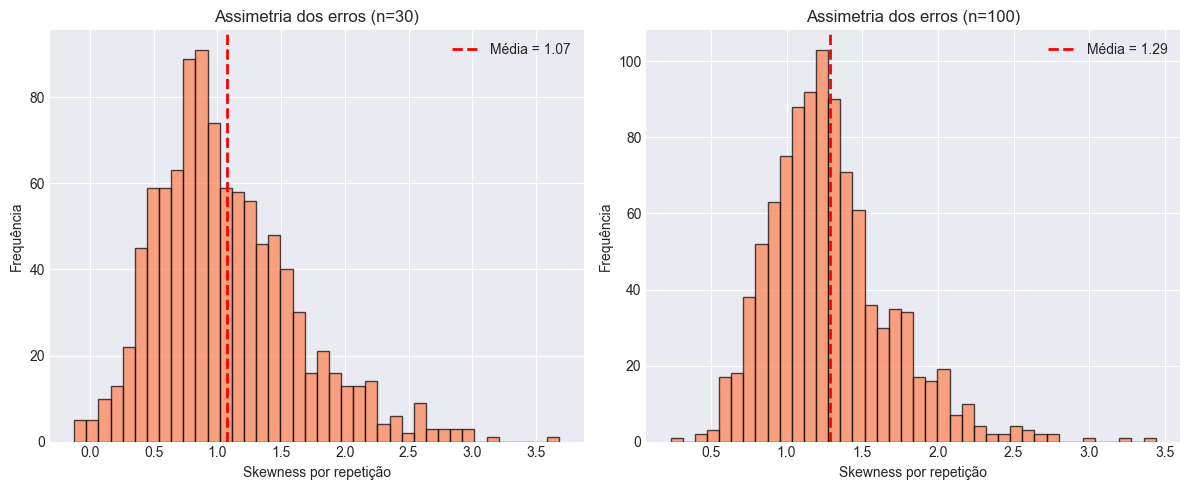

✓ Gráfico de assimetria dos erros salvo.
Interpretação: a distribuição permanece assimétrica, embora centrada em zero.


In [8]:
fig, axes = plt.subplots(1, len(SAMPLE_SIZES), figsize=(12, 5))
if len(SAMPLE_SIZES) == 1:
    axes = [axes]

for idx, n in enumerate(SAMPLE_SIZES):
    ax = axes[idx]
    epsilon_skew = results[n]['epsilon_skew']
    ax.hist(epsilon_skew, bins=40, edgecolor='black', alpha=0.7, color='coral')
    ax.axvline(np.mean(epsilon_skew), color='red', linestyle='--', linewidth=2, label=f'Média = {np.mean(epsilon_skew):.2f}')
    ax.set_title(f'Assimetria dos erros (n={n})')
    ax.set_xlabel('Skewness por repetição')
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.savefig('cenario3_assimetria_erros.png', dpi=100, bbox_inches='tight')
plt.show()

print('✓ Gráfico de assimetria dos erros salvo.')
print('Interpretação: a distribuição permanece assimétrica, embora centrada em zero.')

#### 4.2 Visualizações dos Estimadores

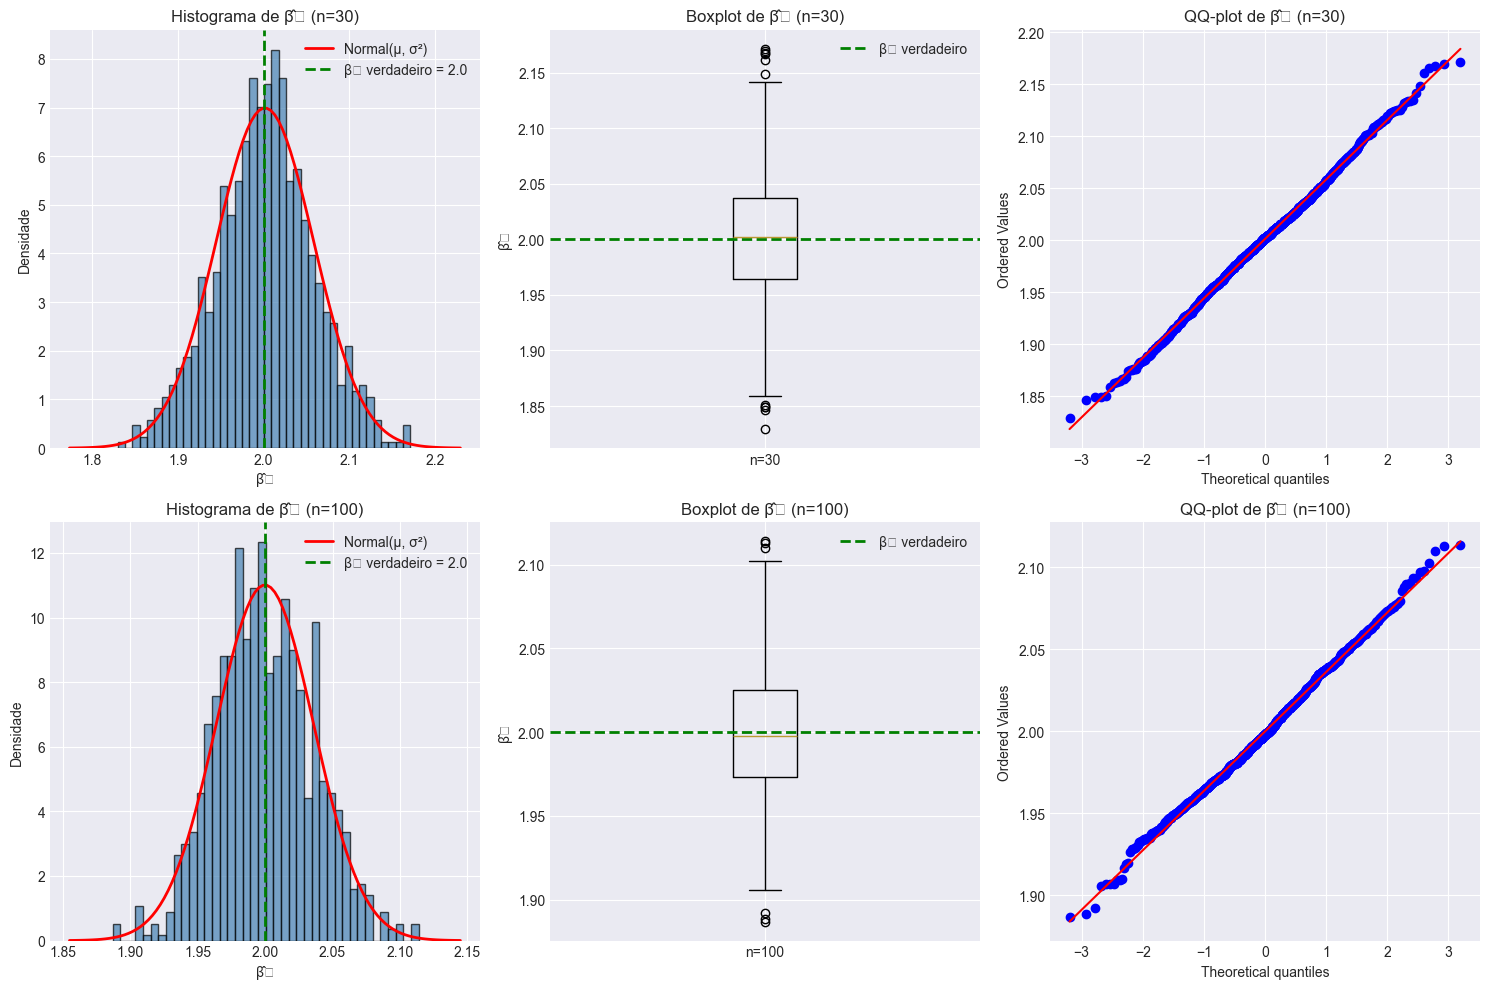

✓ Gráficos dos estimadores salvos.
Observação: a assimetria pode aparecer mais claramente no QQ-plot do que no histograma.


In [9]:
fig, axes = plt.subplots(len(SAMPLE_SIZES), 3, figsize=(15, 5*len(SAMPLE_SIZES)))
if len(SAMPLE_SIZES) == 1:
    axes = axes.reshape(1, -1)

for idx, n in enumerate(SAMPLE_SIZES):
    beta1_samples = results[n]['beta1_hats']

    ax = axes[idx, 0]
    ax.hist(beta1_samples, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    mu_beta1 = np.mean(beta1_samples)
    std_beta1 = np.std(beta1_samples)
    x_range = np.linspace(mu_beta1 - 4 * std_beta1, mu_beta1 + 4 * std_beta1, 100)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_beta1, std_beta1), 'r-', linewidth=2, label='Normal(μ, σ²)')
    ax.axvline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label=f'β₁ verdadeiro = {BETA1_TRUE}')
    ax.set_title(f'Histograma de β̂₁ (n={n})')
    ax.set_xlabel('β̂₁')
    ax.set_ylabel('Densidade')
    ax.legend()

    ax = axes[idx, 1]
    ax.boxplot([beta1_samples], labels=[f'n={n}'], vert=True)
    ax.axhline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label='β₁ verdadeiro')
    ax.set_ylabel('β̂₁')
    ax.set_title(f'Boxplot de β̂₁ (n={n})')
    ax.legend()

    ax = axes[idx, 2]
    stats.probplot(beta1_samples, dist='norm', plot=ax)
    ax.set_title(f'QQ-plot de β̂₁ (n={n})')

plt.tight_layout()
plt.savefig('cenario3_diagnostico_beta1.png', dpi=100, bbox_inches='tight')
plt.show()

print('✓ Gráficos dos estimadores salvos.')
print('Observação: a assimetria pode aparecer mais claramente no QQ-plot do que no histograma.')

#### 4.3 Diagnóstico de Resíduos

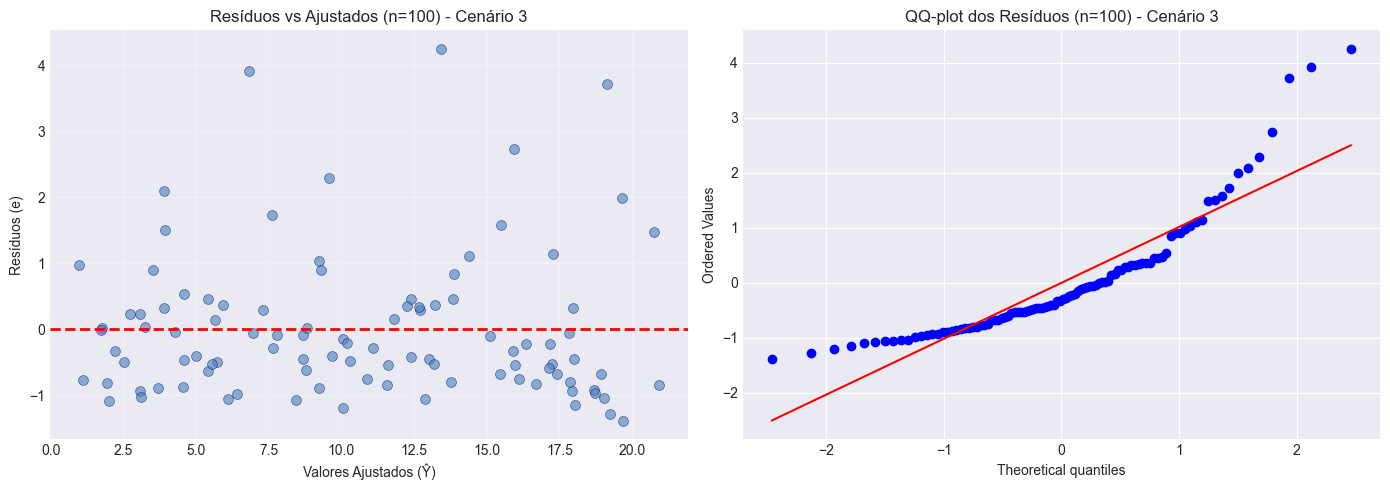

✓ Gráficos de diagnóstico de resíduos (n=100) salvos.
Interpretação para Cenário 3 (Assimetria):
  - Resíduos vs Ajustados tende a manter dispersão aleatória se o modelo linear estiver correto.
  - QQ-plot pode exibir curvatura assimétrica, indicando distribuição não normal dos erros.
  - A média zero mantém o MQO centrado, mas a forma da distribuição impacta a inferência finita.


In [10]:
n_diag = max(SAMPLE_SIZES)
residuals = results[n_diag]['residuals_diagnostic']
fitted = results[n_diag]['fitted_diagnostic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(fitted, residuals, alpha=0.6, s=50, color='steelblue', edgecolor='darkblue', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores Ajustados (Ŷ)')
ax.set_ylabel('Resíduos (e)')
ax.set_title(f'Resíduos vs Ajustados (n={n_diag}) - Cenário 3')
ax.grid(True, alpha=0.3)

ax = axes[1]
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title(f'QQ-plot dos Resíduos (n={n_diag}) - Cenário 3')

plt.tight_layout()
plt.savefig('cenario3_diagnostico_residuos.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'✓ Gráficos de diagnóstico de resíduos (n={n_diag}) salvos.')
print('Interpretação para Cenário 3 (Assimetria):')
print('  - Resíduos vs Ajustados tende a manter dispersão aleatória se o modelo linear estiver correto.')
print('  - QQ-plot pode exibir curvatura assimétrica, indicando distribuição não normal dos erros.')
print('  - A média zero mantém o MQO centrado, mas a forma da distribuição impacta a inferência finita.')

## Resumo e Interpretação Final

### Principais Achados do Cenário 3 (Assimetria)

1. **Estimação**: os estimadores tendem a continuar próximos do valor verdadeiro, pois a condição central é a média zero dos erros.
2. **Inferência**: a cobertura pode se afastar do nominal se a assimetria for forte e a amostra pequena.
3. **Testes**: o desempenho pode ser afetado indiretamente pela forma da distribuição dos erros.
4. **Diagnóstico**: o QQ-plot é a principal evidência visual da assimetria.

### Conclusão

Neste cenário, a mensagem principal é que **média zero não implica normalidade nem simetria**. O MQO continua centrado sob a hipótese correta de exogeneidade, mas a assimetria altera o comportamento amostral, especialmente em amostras menores e na qualidade da aproximação normal usada na inferência.

---

In [ ]:
print('\n' + '='*100)
print('SALVANDO RESULTADOS - CENÁRIO 3')
print('='*100)

output_dir = 'cenario3_resultados'
os.makedirs(output_dir, exist_ok=True)

for name, df in all_results.items():
    filepath = os.path.join(output_dir, f'cenario3_{name}.csv')
    df.to_csv(filepath, index=False)
    print(f'✓ Salvo: {filepath}')

print(f'\n✓ Arquivos salvos no diretório: {output_dir}/')

print('='*100)
print('\n✨ Cenário 3 concluído com sucesso!')
print('Próximo passo natural: comparar os cenários 1, 2 e 3 lado a lado.')
print('='*100)


SALVANDO RESULTADOS - CENÁRIO 3
✓ Salvo: cenario3_resultados\cenario3_estimation.csv
✓ Salvo: cenario3_resultados\cenario3_inference.csv
✓ Salvo: cenario3_resultados\cenario3_tests.csv

✓ Arquivos salvos no diretório: cenario3_resultados/

✨ Cenário 3 concluído com sucesso!
Próximo passo natural: comparar os cenários 1, 2 e 3 lado a lado.
